# Housing Discrimination and Algorithmic Bias
## DATA 6550 — Data Ethics Project | 2025
### Hennepin County & Ramsey County, Minnesota

# AI Disclaimer :

**i use generative ai for the graphs plotting and summaries generating from the code outputs i have done and as i have worked on three csv files i took some help from ai to generate summaries and graphs & tables**

**Datasets used:**
- `mortgage_covenant_data.csv` — 100,931 HMDA 2023 mortgage applications (statewide MN) with Hennepin County covenant density pre-joined
- `covenants-mn-ramsey-county.csv` — 5,528 racial covenant records for Ramsey County (Mapping Prejudice Project)
- `county_27123.csv` — 14,482 full 2023 HMDA mortgage applications for Ramsey County

**Two types of bias this project investigates:**
- **Data Bias** — historical discrimination baked into modern variables like property values and neighborhood demographics
- **Algorithmic Bias** — modern lending systems producing racially unequal outcomes through proxy variables

## Historical Context

**Racial Covenants (1910–1955):** Legal clauses written into property deeds that prohibited sale or occupancy by non-white residents. The Mapping Prejudice Project documented 30,000+ in Hennepin County and 5,528 in Ramsey County. These were standard developer tools used to enforce segregation in new Twin Cities housing developments.

**Redlining:** In the 1930s the federal Home Owners' Loan Corporation (HOLC) color-coded cities, marking Black and immigrant neighborhoods as "hazardous" for mortgage lending. Banks denied loans to redlined areas regardless of individual creditworthiness, locking Black families out of homeownership.

**The GI Bill and Suburban Exclusion:** After WWII the GI Bill made low-cost mortgages available to veterans — but Black veterans were largely denied access. White veterans bought into new covenanted suburbs; Black veterans were steered back into overcrowded urban neighborhoods.

**The Rondo Neighborhood (Saint Paul):** A thriving Black community in Ramsey County that was largely demolished when Interstate 94 was built through it in the 1950s–60s — government-sanctioned displacement while white suburbs were legally protected by covenants.

**The Fair Housing Act (1968):** Covenants were made unenforceable. But 50+ years of exclusion had already created the property value gaps, neighborhood demographics, and wealth disparities that modern data — and modern algorithms — now inherit.

## Section 1: Exploratory Data Analysis

Import the libraries we need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

Load the main dataset and take a first look.

In [2]:
df = pd.read_csv("/content/mortgage_covenant_data.csv")
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [3]:
df.shape

(100931, 14)

In [4]:
df.columns

Index(['activity_year', 'census_tract', 'derived_race', 'action_taken',
       'loan_amount', 'property_value', 'income', 'interest_rate',
       'tract_minority_population_percent', 'tract_to_msa_income_percentage',
       'denial_reason-1', 'covenant_count', 'was_approved',
       'covenant_density'],
      dtype='object')

The column `denial_reason-1` has a hyphen that causes issues later. Rename it now.

In [5]:
df = df.rename(columns={'denial_reason-1': 'denial_reason_1'})

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason_1                    100931 non-null  int64  
 11  covenant_count                     1009

In [7]:
df.describe()

,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason_1,covenant_count
count,100931.0,9.991500e+04,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.708025e+10,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,5.254319e+07,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


In [8]:
df.isnull().sum()

,0
activity_year,0
census_tract,1016
derived_race,0
action_taken,0
loan_amount,0
property_value,17440
income,12731
interest_rate,22806
tract_minority_population_percent,0
tract_to_msa_income_percentage,0


**What I noticed:**
- `covenant_density` has 89,762 missing values — most tracts have no covenant history, only 11,169 records are from covenanted tracts
- `interest_rate`, `property_value`, and `income` have some missing values — handled with `.dropna()` where needed
- `was_approved` has zero nulls — this is our main outcome variable throughout

In [9]:
print(df['was_approved'].value_counts())
print()
print("Overall approval rate:", round(df['was_approved'].mean() * 100, 2), "%")

was_approved
True     67085
False    33846
Name: count, dtype: int64

Overall approval rate: 66.47 %


In [10]:
df['action_taken'].value_counts()

,count
action_taken,
1,65329
6,15687
4,10508
3,5796
2,1756
5,1320
8,375
7,160


In [11]:
df['derived_race'].value_counts()

,count
derived_race,
White,63627
Race Not Available,22811
Asian,5905
Black or African American,5199
Joint,2427
American Indian or Alaska Native,709
2 or more minority races,135
Native Hawaiian or Other Pacific Islander,113
Free Form Text Only,5


In [12]:
print(df['covenant_density'].value_counts(dropna=False))
print()
print("Records WITH covenant data:", df['covenant_density'].notna().sum())
print("Records WITHOUT covenant data:", df['covenant_density'].isna().sum())

covenant_density
NaN                 89762
Low (1-50)           4537
Very High (>200)     3140
Medium (51-100)      1772
High (101-200)       1720
Name: count, dtype: int64

Records WITH covenant data: 11169
Records WITHOUT covenant data: 89762


## Section 2: Data Cleaning and Preparation

Split into covenanted and non-covenanted groups — our main comparison throughout.

In [13]:
cov_df    = df[df['covenant_density'].notna()].copy()
no_cov_df = df[df['covenant_density'].isna()].copy()

print("Covenanted tracts:", len(cov_df))
print("Non-covenanted tracts:", len(no_cov_df))

Covenanted tracts: 11169
Non-covenanted tracts: 89762


Define covenant density category order for charts.

In [14]:
density_order = ['Low (1-50)', 'Medium (51-100)', 'High (101-200)', 'Very High (>200)']
cov_df['covenant_density'].value_counts().reindex(density_order)

,count
covenant_density,
Low (1-50),4537
Medium (51-100),1772
High (101-200),1720
Very High (>200),3140


Map denial reason codes to readable labels.

In [15]:
denial_map = {
    1: 'Credit History',
    2: 'Income',
    3: 'Collateral / Property Value',
    4: 'Insufficient Cash',
    5: 'Unverifiable Info',
    6: 'Incomplete Application',
    7: 'Mortgage Insurance Denied',
    8: 'Other',
    9: 'Other',
    10: 'Not Applicable',
    1111: 'Not Applicable'
}
df['denial_reason_label'] = df['denial_reason_1'].map(denial_map).fillna('Other')

In [16]:
denied_df = df[df['was_approved'] == False]
denied_df['denial_reason_label'].value_counts().head(8)

,count
denial_reason_label,
Not Applicable,28035
Credit History,2231
Collateral / Property Value,1204
Insufficient Cash,773
Other,472
Mortgage Insurance Denied,401
Unverifiable Info,279
Incomplete Application,271


Flag Ramsey County records from the main dataset — their census tracts start with `27123`.

In [17]:
df['is_ramsey'] = df['census_tract'].astype(str).str.startswith('27123')
ramsey_df = df[df['is_ramsey'] == True].copy()

print("Ramsey County applications:", len(ramsey_df))
print("Ramsey approval rate:", round(ramsey_df['was_approved'].mean() * 100, 1), "%")

Ramsey County applications: 8782
Ramsey approval rate: 65.0 %


## Section 3: Data Bias Analysis

Data bias is when historical discrimination gets hidden inside modern variables. Property values look like a neutral financial number — but neighborhoods that had racial covenants received decades of exclusive investment and have much higher values today. When a lending algorithm uses property value, it is unknowingly using a variable shaped by racism.

Build a comparison table of key metrics between covenanted and non-covenanted tracts.

In [18]:
comparison = pd.DataFrame({
    'Metric': ['Approval Rate', 'Median Property Value', 'Mean Interest Rate',
               'Mean Minority Population %', 'Median Income ($000s)'],
    'Covenanted Tracts': [
        f"{cov_df['was_approved'].mean():.1%}",
        f"${cov_df['property_value'].median()/1000:.0f}k",
        f"{cov_df['interest_rate'].mean():.2f}%",
        f"{cov_df['tract_minority_population_percent'].mean():.1f}%",
        f"{cov_df['income'].median():.0f}"
    ],
    'Non-Covenanted Tracts': [
        f"{no_cov_df['was_approved'].mean():.1%}",
        f"${no_cov_df['property_value'].median()/1000:.0f}k",
        f"{no_cov_df['interest_rate'].mean():.2f}%",
        f"{no_cov_df['tract_minority_population_percent'].mean():.1f}%",
        f"{no_cov_df['income'].median():.0f}"
    ]
})
comparison

,Metric,Covenanted Tracts,Non-Covenanted Tracts
0,Approval Rate,67.1%,66.4%
1,Median Property Value,$355k,$315k
2,Mean Interest Rate,6.61%,6.57%
3,Mean Minority Population %,30.4%,21.9%
4,Median Income ($000s),111,94


Property values are $40k HIGHER in covenanted tracts ($355k vs $315k). Covenants were applied to desirable suburbs that got sustained investment for decades — `property_value` carries that racial history inside it.

In [19]:
pv_by_density = cov_df.groupby('covenant_density')['property_value'].median().reindex(density_order) / 1000
pv_by_density

,property_value
covenant_density,
Low (1-50),325.0
Medium (51-100),365.0
High (101-200),375.0
Very High (>200),385.0


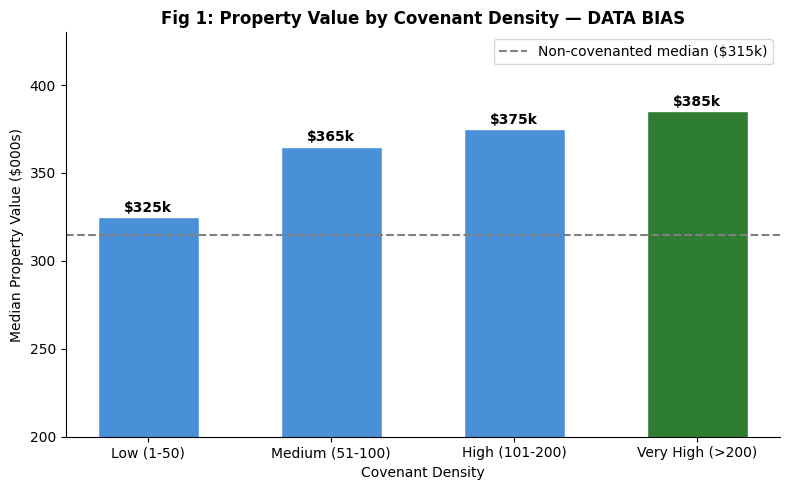

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(density_order, pv_by_density, color=['#4A90D9','#4A90D9','#4A90D9','#2E7D32'], width=0.55, edgecolor='white')
ax.axhline(no_cov_df['property_value'].median()/1000, color='gray', linestyle='--', linewidth=1.5, label='Non-covenanted median ($315k)')
for bar, val in zip(bars, pv_by_density):
    ax.text(bar.get_x()+bar.get_width()/2, val+3, f'${val:.0f}k', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(200, 430)
ax.set_xlabel('Covenant Density')
ax.set_ylabel('Median Property Value ($000s)')
ax.set_title('Fig 1: Property Value by Covenant Density — DATA BIAS', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_property_value.png', dpi=150, bbox_inches='tight')
plt.show()

Run a t-test to confirm the property value difference is statistically significant.

In [21]:
t_stat, p_val = stats.ttest_ind(
    cov_df['property_value'].dropna(),
    no_cov_df['property_value'].dropna()
)
print(f"t-statistic = {t_stat:.2f}")
print(f"p-value     = {p_val:.6f}")
print()
if p_val < 0.05:
    print("STATISTICALLY SIGNIFICANT — the difference is not due to random chance.")

t-statistic = 7.61
p-value     = 0.000000

STATISTICALLY SIGNIFICANT — the difference is not due to random chance.


In [22]:
mp_by_density = cov_df.groupby('covenant_density')['tract_minority_population_percent'].mean().reindex(density_order)
mp_by_density

,tract_minority_population_percent
covenant_density,
Low (1-50),37.501120
Medium (51-100),26.929069
High (101-200),24.150360
Very High (>200),25.431010


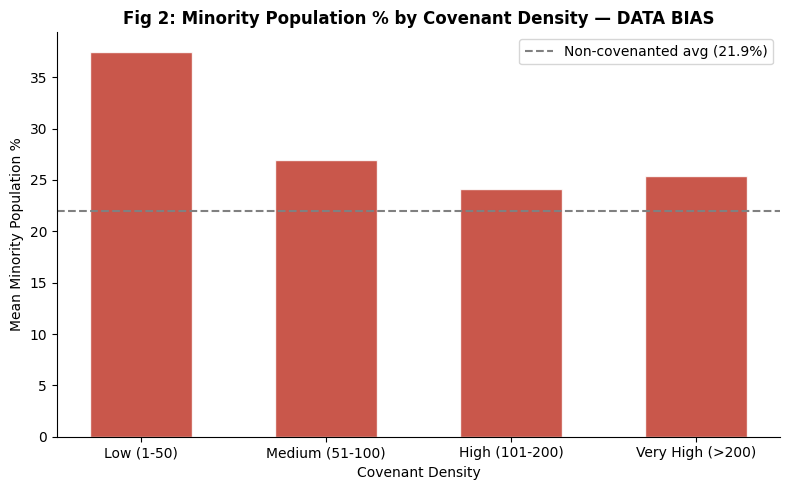

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(density_order, mp_by_density, color='#C0392B', width=0.55, edgecolor='white', alpha=0.85)
ax.axhline(no_cov_df['tract_minority_population_percent'].mean(), color='gray', linestyle='--', linewidth=1.5,
           label=f"Non-covenanted avg ({no_cov_df['tract_minority_population_percent'].mean():.1f}%)")
for bar, val in zip(bars, mp_by_density):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='white')
ax.set_xlabel('Covenant Density')
ax.set_ylabel('Mean Minority Population %')
ax.set_title('Fig 2: Minority Population % by Covenant Density — DATA BIAS', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_minority_pct.png', dpi=150, bbox_inches='tight')
plt.show()

Low-density covenanted tracts (37.5%) show the highest minority % — these are border/transition zones where enforcement was contested. Very High density tracts (25.4%) stayed more white because exclusion was most thorough there. Non-covenanted tracts average 21.9%.

In [24]:
income_by_density = cov_df.groupby('covenant_density')['income'].median().reindex(density_order)
income_by_density

,income
covenant_density,
Low (1-50),100.0
Medium (51-100),112.0
High (101-200),117.0
Very High (>200),128.0


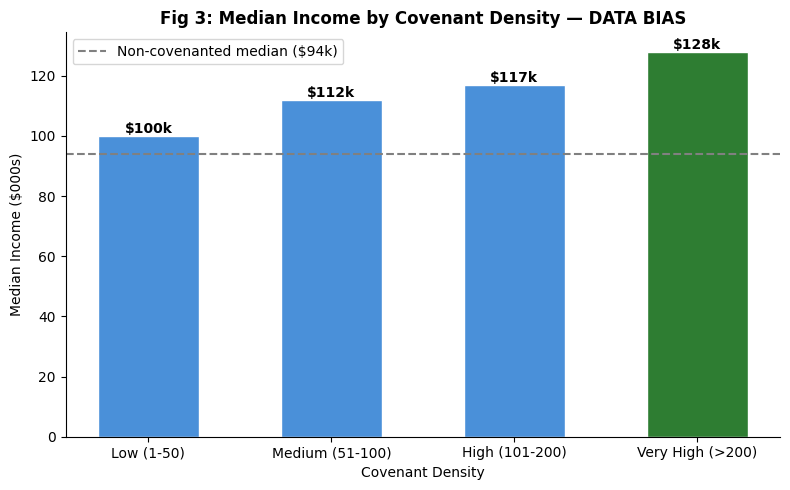

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(density_order, income_by_density, color=['#4A90D9','#4A90D9','#4A90D9','#2E7D32'], width=0.55, edgecolor='white')
ax.axhline(no_cov_df['income'].median(), color='gray', linestyle='--', linewidth=1.5,
           label=f"Non-covenanted median (${no_cov_df['income'].median():.0f}k)")
for bar, val in zip(bars, income_by_density):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'${val:.0f}k', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Covenant Density')
ax.set_ylabel('Median Income ($000s)')
ax.set_title('Fig 3: Median Income by Covenant Density — DATA BIAS', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_income.png', dpi=150, bbox_inches='tight')
plt.show()

Median income rises with covenant density: Low=$100k, Medium=$112k, High=$117k, Very High=$128k vs $94k non-covenanted. Covenanted suburbs concentrated wealth over decades — applicants from those tracts arrive today with higher incomes, making the racial gaps there even more significant.

## Section 4: Algorithmic Bias Analysis

Algorithmic bias is when a system produces racially unequal outcomes even without explicitly using race. We look at approval rates, the Black-White gap, and interest rate differences.

In [26]:
race_approval = df.groupby('derived_race')['was_approved'].agg(['mean','count']).reset_index()
race_approval.columns = ['Race', 'Approval Rate', 'Count']
race_approval['Approval Rate %'] = (race_approval['Approval Rate'] * 100).round(1)
race_approval = race_approval.sort_values('Approval Rate', ascending=False)
race_approval[['Race', 'Approval Rate %', 'Count']]

,Race,Approval Rate %,Count
4,Free Form Text Only,80.0,5
8,White,75.6,63627
5,Joint,74.4,2427
2,Asian,70.8,5905
0,2 or more minority races,65.9,135
1,American Indian or Alaska Native,62.2,709
3,Black or African American,60.4,5199
6,Native Hawaiian or Other Pacific Islander,56.6,113
7,Race Not Available,40.6,22811


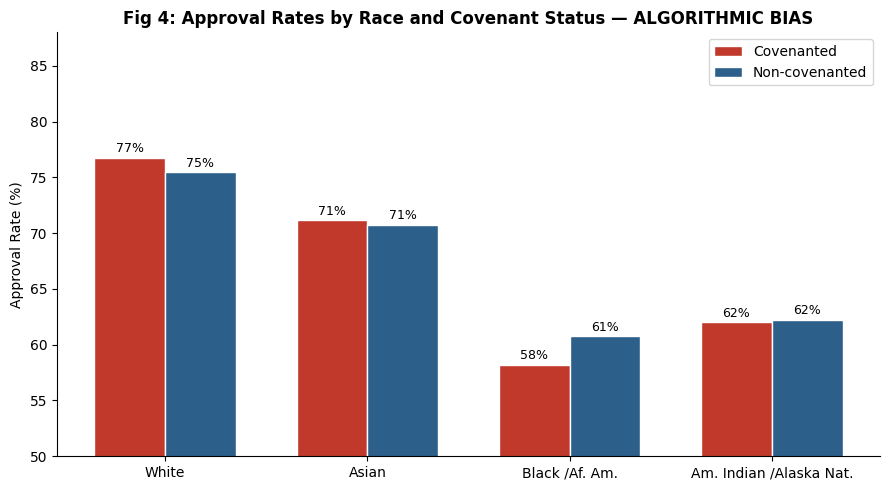

In [27]:
key_races    = ['White', 'Asian', 'Black or African American', 'American Indian or Alaska Native']
short_labels = ['White', 'Asian', 'Black /Af. Am.', 'Am. Indian /Alaska Nat.']

rates_cov  = [cov_df[cov_df['derived_race']==r]['was_approved'].mean()*100 for r in key_races]
rates_ncov = [no_cov_df[no_cov_df['derived_race']==r]['was_approved'].mean()*100 for r in key_races]

x = np.arange(len(key_races))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, rates_cov,  w, label='Covenanted',     color='#C0392B', edgecolor='white')
b2 = ax.bar(x+w/2, rates_ncov, w, label='Non-covenanted', color='#2C5F8A', edgecolor='white')
for bar, val in zip(b1, rates_cov):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=9)
for bar, val in zip(b2, rates_ncov):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_ylim(50, 88)
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Fig 4: Approval Rates by Race and Covenant Status — ALGORITHMIC BIAS', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_approval_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
bk_cov  = cov_df[cov_df['derived_race']=='Black or African American']['was_approved'].mean()
wh_cov  = cov_df[cov_df['derived_race']=='White']['was_approved'].mean()
bk_ncov = no_cov_df[no_cov_df['derived_race']=='Black or African American']['was_approved'].mean()
wh_ncov = no_cov_df[no_cov_df['derived_race']=='White']['was_approved'].mean()

print("In COVENANTED tracts:")
print(f"  White: {wh_cov:.1%}  |  Black: {bk_cov:.1%}  |  Gap: {wh_cov-bk_cov:.1%}")
print()
print("In NON-COVENANTED tracts:")
print(f"  White: {wh_ncov:.1%}  |  Black: {bk_ncov:.1%}  |  Gap: {wh_ncov-bk_ncov:.1%}")
print()
print("The gap is LARGER in historically covenanted areas.")

In COVENANTED tracts:
  White: 76.7%  |  Black: 58.2%  |  Gap: 18.5%

In NON-COVENANTED tracts:
  White: 75.5%  |  Black: 60.7%  |  Gap: 14.7%

The gap is LARGER in historically covenanted areas.


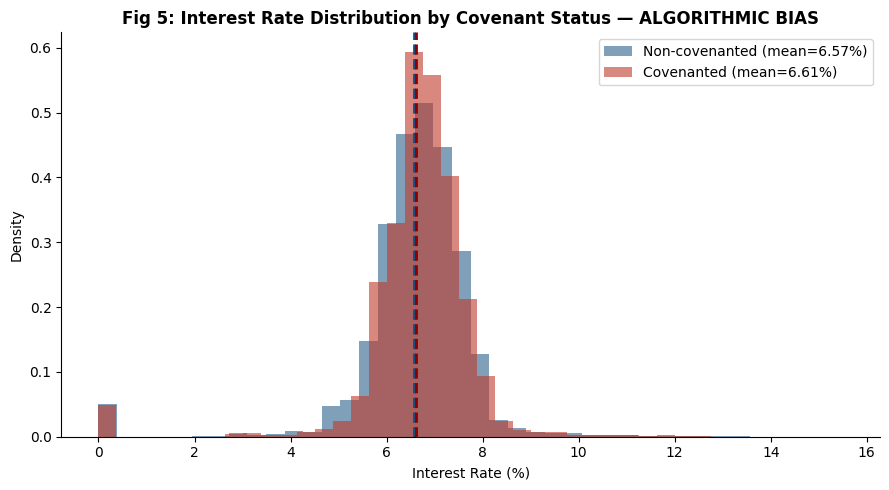

In [29]:
ir_cov  = cov_df['interest_rate'].dropna()
ir_ncov = no_cov_df['interest_rate'].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ir_ncov, bins=40, alpha=0.6, color='#2C5F8A', density=True, label=f'Non-covenanted (mean={ir_ncov.mean():.2f}%)')
ax.hist(ir_cov,  bins=40, alpha=0.6, color='#C0392B', density=True, label=f'Covenanted (mean={ir_cov.mean():.2f}%)')
ax.axvline(ir_ncov.mean(), color='#1A4B7A', linewidth=2, linestyle='--')
ax.axvline(ir_cov.mean(),  color='#8B0000', linewidth=2, linestyle='--')
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Density')
ax.set_title('Fig 5: Interest Rate Distribution by Covenant Status — ALGORITHMIC BIAS', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_interest_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
t_ir, p_ir = stats.ttest_ind(ir_cov, ir_ncov)

print(f"Covenanted: {ir_cov.mean():.3f}%  |  Non-covenanted: {ir_ncov.mean():.3f}%")
print(f"Difference: {ir_cov.mean()-ir_ncov.mean():.4f}%")
print(f"t = {t_ir:.2f},  p = {p_ir:.4f}")
print()
extra = 350000 * (ir_cov.mean()-ir_ncov.mean())/100/12 * 360
print(f"On a $350,000 / 30-year mortgage — extra interest paid: ${extra:,.0f}")

Covenanted: 6.610%  |  Non-covenanted: 6.571%
Difference: 0.0398%
t = 2.79,  p = 0.0053

On a $350,000 / 30-year mortgage — extra interest paid: $4,183


In [31]:
approval_by_density = cov_df.groupby('covenant_density')['was_approved'].mean().reindex(density_order) * 100
approval_by_density

,was_approved
covenant_density,
Low (1-50),66.122989
Medium (51-100),67.042889
High (101-200),69.244186
Very High (>200),67.388535


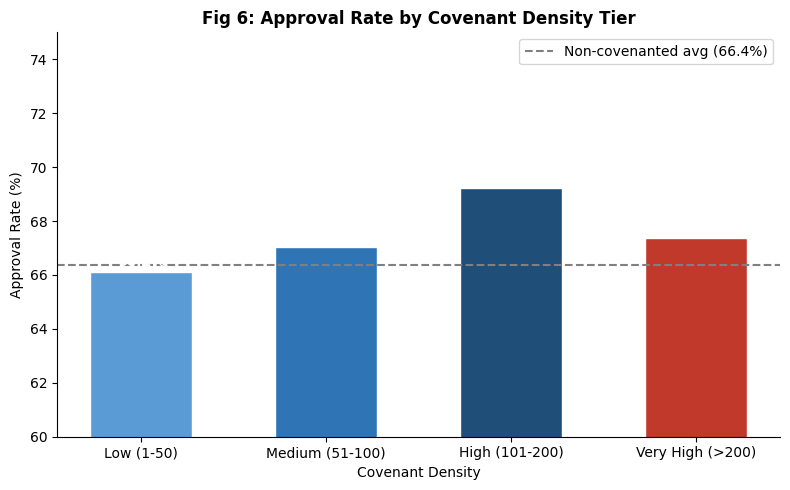

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(density_order, approval_by_density,
              color=['#5B9BD5','#2F75B6','#1F4E79','#C0392B'], width=0.55, edgecolor='white')
ax.axhline(no_cov_df['was_approved'].mean()*100, color='gray', linestyle='--', linewidth=1.5,
           label=f"Non-covenanted avg ({no_cov_df['was_approved'].mean():.1%})")
for bar, val in zip(bars, approval_by_density):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.2, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='white')
ax.set_ylim(60, 75)
ax.set_xlabel('Covenant Density')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Fig 6: Approval Rate by Covenant Density Tier', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_approval_density.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Proxy Variable Analysis

A proxy variable looks neutral but acts as a stand-in for race because it was shaped by discrimination. We use logistic regression to find which variables most drive mortgage approval.

In [33]:
features = ['loan_amount', 'property_value', 'income', 'interest_rate',
            'tract_minority_population_percent', 'tract_to_msa_income_percentage', 'covenant_count']

model_df = df[features + ['was_approved']].dropna()
print(f"Rows used for model: {len(model_df):,}")

Rows used for model: 67,070


In [34]:
X = model_df[features]
y = model_df['was_approved'].astype(int)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

print(f"Model Accuracy: {lr.score(X_scaled, y):.1%}")

Model Accuracy: 90.3%


In [36]:
coef_df = pd.DataFrame({
    'Variable':    features,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)
coef_df

,Variable,Coefficient
0,property_value,1.541869
1,loan_amount,-1.274420
2,income,0.526190
3,tract_to_msa_income_percentage,0.293591
4,interest_rate,-0.124016
5,tract_minority_population_percent,-0.077328
6,covenant_count,-0.021129


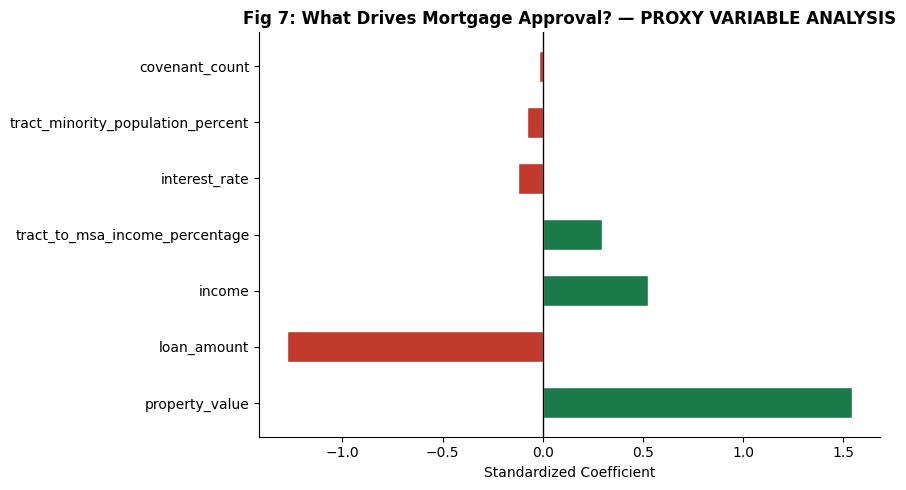

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1A7A4A' if v > 0 else '#C0392B' for v in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Fig 7: What Drives Mortgage Approval? — PROXY VARIABLE ANALYSIS', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig7_proxy_variables.png', dpi=150, bbox_inches='tight')
plt.show()

`property_value` is the strongest predictor at +1.54 — nearly double the next variable. We showed in Section 3 that property values are $40k higher in covenanted tracts due to racial history. The algorithm uses this variable first, inheriting that history through a number.

`tract_minority_population_percent` has a coefficient of −0.077 even after controlling for income, loan amount, and property value. Living in a higher-minority neighborhood reduces approval odds independent of all financial factors — that is direct algorithmic bias.

`covenant_count` is also negative (−0.021). More historical covenants in a tract slightly reduces approval probability after financial controls — bias signal from the historical record itself.

## Section 6: Ramsey County Extension

We extend the analysis using two dedicated Ramsey County files:
- `covenants-mn-ramsey-county.csv` — the historical covenant records
- `county_27123.csv` — full 2023 HMDA mortgage data for Ramsey County

### 6.1 Ramsey County Covenant Records

In [38]:
ramsey_cov = pd.read_csv("/content/covenants-mn-ramsey-county.csv")
print("Shape:", ramsey_cov.shape)
ramsey_cov.head()

Shape: (5528, 38)


,db_id,workflow,cnty_name,cnty_fips,doc_num,deed_year,deed_date,exec_date,cov_text,seller,buyer,street_add,city,state,zip_code,add_cov,block_cov,lot_cov,map_book,map_page,cnty_pin,add_mod,block_mod,lot_mod,ph_dsc_mod,join_strgs,geocd_addr,geocd_dist,cov_type,match_type,manual_cx,dt_updated,zn_subj_id,zn_dt_ret,image_ids,med_score,plat_dbid,subd_dbid
0,2882191,6,Ramsey,27123,897801,1936,1936-05-11,NaN,"That said premises and lots, or any of them, s...",Northline Corporation,NaN,1896 KENNARD ST N,MAPLEWOOD,MN,55109,garden acres,2,"6,7,13,14,15,16,17,18,19,24,25,26,27,28,29,30,...",NaN,NaN,152922410076,GARDEN ACRES,2,48,GARDEN ACRES EX S 4O FT LOT 48 BLK 2,NaN,NaN,NaN,manual,Plat covenant,True,2025-07-01 22:59:03.214101+00:00,NaN,NaN,",,",NaN,7039.0,NaN
1,3034324,6,Ramsey,27123,897801,1936,1936-05-11,NaN,"That said premises and lots, or any of them, s...",Trustees of Morris Fink Estate,NaN,1826 FLANDRAU ST N,MAPLEWOOD,MN,55109,garden acres,1,"1,2,3,4,16,19,20,21,27,28,29,30,31,32,36,37,38...",NaN,NaN,152922410019,GARDEN ACRES,1,40,GARDEN ACRES S 1/2 OF LOT 40 BLK 1,garden acres block 1 lot 1;garden acres block ...,NaN,NaN,manual,Something else,True,2024-02-13 21:13:25.113447+00:00,NaN,NaN,",,",NaN,7039.0,NaN
2,3034320,6,Ramsey,27123,897801,1936,1936-05-11,NaN,"That said premises and lots, or any of them, s...",Northline Corporation,NaN,1838 FLANDRAU ST N,MAPLEWOOD,MN,55109,garden acres,1,"25,26,35,41,42",NaN,NaN,152922410022,GARDEN ACRES,1,41,GARDEN ACRES N 1/2 OF LOT 41 BLK 1,garden acres block 1 lot 25;garden acres block...,NaN,NaN,manual,Something else,True,2024-02-13 21:13:39.354619+00:00,NaN,NaN,",,",NaN,7039.0,NaN
3,2914680,6,Ramsey,27123,897801,1936,1936-05-11,NaN,"That said premises and lots, or any of them, s...",Trustees of Morris Fink Estate,NaN,1919 FLANDRAU ST N,MAPLEWOOD,MN,55109,garden acres,2,"1,2,3,4,5,9,10,11,22,41,42,43,44,45,46",NaN,NaN,152922410084,GARDEN ACRES,2,2,GARDEN ACRES EX W 75 FT; THE N 1/2 OF LOT 2 B...,garden acres block 2 lot 1;garden acres block ...,NaN,NaN,manual,Public submission (single property),True,2024-02-13 20:55:02.118541+00:00,NaN,NaN,",,",NaN,7039.0,NaN
4,3035078,6,Ramsey,27123,897801,1936,1936-05-11,NaN,"That said premises and lots, or any of them, s...",Trustees of Morris Fink Estate,NaN,1899 WHITE BEAR AVE N,MAPLEWOOD,MN,55109,garden acres,1,"1,2,3,4,16,19,20,21,27,28,29,30,31,32,36,37,38...",NaN,NaN,152922410006,GARDEN ACRES,1,4,GARDEN ACRES SUBJ TO ROW ESMT PER DOC NO 4986...,garden acres block 1 lot 1;garden acres block ...,NaN,NaN,manual,Something else,True,2024-02-13 21:13:25.113447+00:00,NaN,NaN,",,",NaN,7039.0,NaN


In [39]:
print(f"Total covenant records : {len(ramsey_cov):,}")
print(f"Year range             : {ramsey_cov['deed_year'].min()} to {ramsey_cov['deed_year'].max()}")
print()
print("Top cities with covenants:")
print(ramsey_cov['city'].value_counts().head(8))

Total covenant records : 5,528
Year range             : 1913 to 1961

Top cities with covenants:
city
ST PAUL            2566
ROSEVILLE           668
FALCON HEIGHTS      605
MOUNDS VIEW         515
MAPLEWOOD           434
WHITE BEAR LAKE     197
ARDEN HILLS         144
SHOREVIEW           136
Name: count, dtype: int64


In [40]:
ramsey_cov['decade'] = (ramsey_cov['deed_year'] // 10) * 10
ramsey_cov['decade'].value_counts().sort_index()

,count
decade,
1910,349
1920,1422
1930,965
1940,2304
1950,480
1960,8


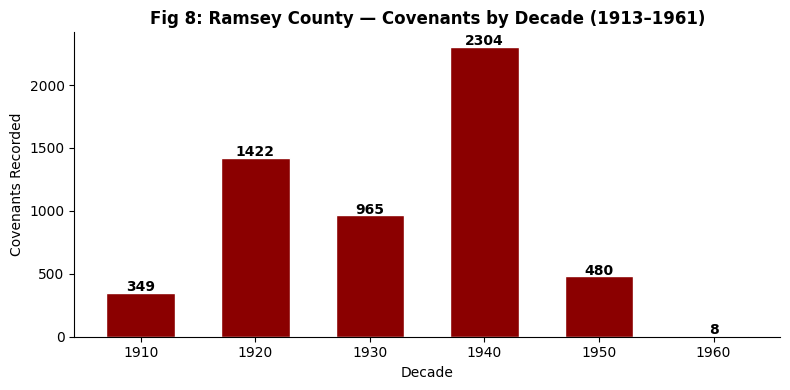

In [41]:
decade_counts = ramsey_cov['decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(decade_counts.index.astype(str), decade_counts.values, color='#8B0000', width=0.6, edgecolor='white')
for bar, val in zip(bars, decade_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+12, str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Covenants Recorded')
ax.set_title('Fig 8: Ramsey County — Covenants by Decade (1913–1961)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_ramsey_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

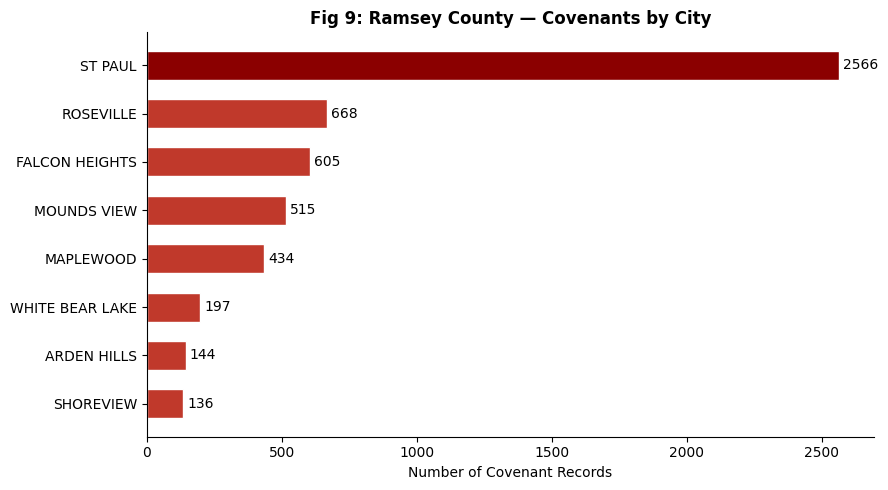

In [42]:
city_counts = ramsey_cov['city'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#8B0000' if c == 'ST PAUL' else '#C0392B' for c in city_counts.index]
ax.barh(city_counts.index[::-1], city_counts.values[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for i, val in enumerate(city_counts.values[::-1]):
    ax.text(val+15, i, str(val), va='center', fontsize=10)
ax.set_xlabel('Number of Covenant Records')
ax.set_title('Fig 9: Ramsey County — Covenants by City', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig9_ramsey_cities.png', dpi=150, bbox_inches='tight')
plt.show()

Count covenants by zip code to see which neighborhoods had the most exclusion.

In [43]:
zip_labels = {
    55108: 'Como / St. Anthony Park',   55113: 'Roseville',
    55112: 'Mounds View / New Brighton', 55116: 'Highland Park / Mac-Groveland',
    55119: 'Battle Creek / Highwood',    55109: 'Maplewood',
    55117: 'North St. Paul / Little Canada', 55110: 'White Bear Lake',
    55126: 'Shoreview',  55105: 'Summit Hill',
    55106: 'Payne-Phalen / East Side',  55104: 'Hamline-Midway',
    55102: 'West Seventh / Downtown',   55130: 'Dayton Bluff'
}

cov_by_zip = ramsey_cov.groupby('zip_code').size().reset_index(name='covenant_count')
cov_by_zip['neighborhood'] = cov_by_zip['zip_code'].map(zip_labels).fillna('Other')
cov_by_zip.sort_values('covenant_count', ascending=False)

,zip_code,covenant_count,neighborhood
4,55108,1110,Como / St. Anthony Park
8,55113,1033,Roseville
7,55112,703,Mounds View / New Brighton
10,55116,663,Highland Park / Mac-Groveland
12,55119,566,Battle Creek / Highwood
5,55109,426,Maplewood
11,55117,406,North St. Paul / Little Canada
6,55110,215,White Bear Lake
13,55126,138,Shoreview
2,55105,87,Summit Hill


Print a sample of the actual covenant language from the deeds.

In [44]:
print("=== Sample Covenant Language from Ramsey County Deeds ===\n")
for _, row in ramsey_cov[['deed_year', 'city', 'cov_text']].dropna().head(3).iterrows():
    print(f"Year: {row['deed_year']}  |  City: {row['city']}")
    print(f"Text: {str(row['cov_text'])[:220]}...")
    print()

=== Sample Covenant Language from Ramsey County Deeds ===

Year: 1936  |  City: MAPLEWOOD
Text: That said premises and lots, or any of them, shall not be sold, leased to, or occupied by any person or persons other than those of the White  Caucasian Race, but such restrictions shall not prevent the occupation of sai...

Year: 1936  |  City: MAPLEWOOD
Text: That said premises and lots, or any of them, shall not be sold, leased to, or occupied by any person or persons other than those of the White  Caucasian Race, but such restrictions shall not prevent the occupation of sai...

Year: 1936  |  City: MAPLEWOOD
Text: That said premises and lots, or any of them, shall not be sold, leased to, or occupied by any person or persons other than those of the White  Caucasian Race, but such restrictions shall not prevent the occupation of sai...



### 6.2 Ramsey County HMDA Data (county_27123.csv)

In [45]:
ramsey_hmda = pd.read_csv("/content/county_27123.csv")
print("Shape:", ramsey_hmda.shape)
print("Columns:", len(ramsey_hmda.columns))
ramsey_hmda.head()

Shape: (14482, 99)
Columns: 99


,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,derived_race,derived_sex,action_taken,purchaser_type,preapproval,loan_type,loan_purpose,lien_status,reverse_mortgage,open-end_line_of_credit,business_or_commercial_purpose,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,hoepa_status,total_loan_costs,total_points_and_fees,origination_charges,discount_points,lender_credits,loan_term,prepayment_penalty_term,intro_rate_period,negative_amortization,interest_only_payment,balloon_payment,other_nonamortizing_features,property_value,construction_method,occupancy_type,manufactured_home_secured_property_type,manufactured_home_land_property_interest,total_units,multifamily_affordable_units,income,debt_to_income_ratio,applicant_credit_score_type,co-applicant_credit_score_type,applicant_ethnicity-1,applicant_ethnicity-2,applicant_ethnicity-3,applicant_ethnicity-4,applicant_ethnicity-5,co-applicant_ethnicity-1,co-applicant_ethnicity-2,co-applicant_ethnicity-3,co-applicant_ethnicity-4,co-applicant_ethnicity-5,applicant_ethnicity_observed,co-applicant_ethnicity_observed,applicant_race-1,applicant_race-2,applicant_race-3,applicant_race-4,applicant_race-5,co-applicant_race-1,co-applicant_race-2,co-applicant_race-3,co-applicant_race-4,co-applicant_race-5,applicant_race_observed,co-applicant_race_observed,applicant_sex,co-applicant_sex,applicant_sex_observed,co-applicant_sex_observed,applicant_age,co-applicant_age,applicant_age_above_62,co-applicant_age_above_62,submission_of_application,initially_payable_to_institution,aus-1,aus-2,aus-3,aus-4,aus-5,denial_reason-1,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2023,549300VZVN841I2ILS84,33460,MN,27123,2.712304e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Joint,Joint,1,1,2,1,1,1,2,2,2,665000.0,85.00000,7.200,0.992,2,11211.00,NaN,8071.50,6672.50,NaN,360,NaN,NaN,2,2,2,2,785000,1,1,3,5,1,NaN,223.0,47,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,2,5.0,27.0,NaN,NaN,5,NaN,NaN,NaN,NaN,2,2,1,2,2,2,25-34,25-34,No,No,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,5859,14.64,124300,210.86,1742,1848,27
1,2023,549300VZVN841I2ILS84,33460,MN,27123,2.712304e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,Asian,Joint,4,0,2,1,1,1,2,2,2,635000.0,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,360,NaN,NaN,2,2,2,2,NaN,1,1,3,5,1,NaN,373.0,NaN,9,9,2.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,2,2,2,21.0,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,2,2,2,1,2,2,25-34,25-34,No,No,1,1,2,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,4278,26.34,124300,120.80,1730,1881,34
2,2023,549300VZVN841I2ILS84,33460,MN,27123,2.712304e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,1,3,2,1,1,1,2,2,2,155000.0,26.08700,6.875,0.389,2,4713.00,NaN,2561.00,1071.00,594.00,360,NaN,NaN,2,2,2,2,575000,1,1,3,5,1,NaN,134.0,46,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,2,2,1,1,2,2,55-64,65-74,No,Yes,1,1,2,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,4110,19.12,124300,91.96,864,1173,36
3,2023,549300VZVN841I2ILS84,33460,MN,27123,2.712304e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Joint,1,6,2,1,1,1,2,2,2,205000.0,95.00000,7.125,0.826,2,6192.56,NaN,3776.56,2286.56,9.00,360,NaN,NaN,2,2,2,2,215000,1,1,3,5,1,NaN,68.0,30%-<36%,1,9,2.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2,2,5,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,2,2,1,2,2,2,55-64,55-64,No,No,1,1,1,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,5987,26.27,124300,101.45,1534,1817,39
4,2023,549300VZVN841I2ILS84,33460,MN,27123,2.712303e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,White,Male,4,0,2,1,1,1,

In [46]:
ramsey_hmda['was_approved']       = ramsey_hmda['action_taken'].isin([1, 2])
ramsey_hmda['property_value_num'] = pd.to_numeric(ramsey_hmda['property_value'], errors='coerce')
ramsey_hmda['interest_rate_num']  = pd.to_numeric(ramsey_hmda['interest_rate'],  errors='coerce')

print(f"Total applications : {len(ramsey_hmda):,}")
print(f"Overall approval   : {ramsey_hmda['was_approved'].mean():.1%}")
print(f"Unique tracts      : {ramsey_hmda['census_tract'].nunique()}")

Total applications : 14,482
Overall approval   : 60.8%
Unique tracts      : 142


In [47]:
race_approval_r = ramsey_hmda.groupby('derived_race')['was_approved'].agg(['mean','count']).reset_index()
race_approval_r.columns = ['Race', 'Approval Rate', 'Count']
race_approval_r['Approval Rate %'] = (race_approval_r['Approval Rate'] * 100).round(1)
race_approval_r.sort_values('Approval Rate', ascending=False)[['Race','Approval Rate %','Count']]

,Race,Approval Rate %,Count
4,Joint,71.6,356
7,White,67.5,8367
2,Asian,61.0,1594
1,American Indian or Alaska Native,60.3,116
5,Native Hawaiian or Other Pacific Islander,52.6,19
3,Black or African American,50.6,891
0,2 or more minority races,44.4,27
6,Race Not Available,44.4,3112


In [48]:
bk_ram = ramsey_hmda[ramsey_hmda['derived_race']=='Black or African American']['was_approved'].mean()
wh_ram = ramsey_hmda[ramsey_hmda['derived_race']=='White']['was_approved'].mean()

print(f"White : {wh_ram:.1%}")
print(f"Black : {bk_ram:.1%}")
print(f"Gap   : {wh_ram - bk_ram:.1%}")

White : 67.5%
Black : 50.6%
Gap   : 16.9%


### 6.3 Tract-Level Analysis — Covenant Proxy

Because the covenant CSV does not have census tract IDs and the HMDA file does not have zip codes, we cannot directly join the two files. Instead, we use `tract_minority_population_percent` as a proxy for covenant impact — the same variable used in the Hennepin analysis. Low-minority tracts correspond to the suburban areas with the most covenant activity; high-minority tracts correspond to historically excluded areas.

In [49]:
q25 = ramsey_hmda['tract_minority_population_percent'].quantile(0.25)
q75 = ramsey_hmda['tract_minority_population_percent'].quantile(0.75)

print(f"Tract minority pop % — Mean: {ramsey_hmda['tract_minority_population_percent'].mean():.1f}%")
print(f"Tract minority pop % — Median: {ramsey_hmda['tract_minority_population_percent'].median():.1f}%")
print(f"Q25 = {q25:.1f}%  (threshold for likely covenanted tracts)")
print(f"Q75 = {q75:.1f}%  (threshold for historically excluded tracts)")

Tract minority pop % — Mean: 40.2%
Tract minority pop % — Median: 34.3%
Q25 = 21.3%  (threshold for likely covenanted tracts)
Q75 = 59.3%  (threshold for historically excluded tracts)


In [50]:
low_min  = ramsey_hmda[ramsey_hmda['tract_minority_population_percent'] <= q25].copy()
high_min = ramsey_hmda[ramsey_hmda['tract_minority_population_percent'] >= q75].copy()

bk_low  = low_min[low_min['derived_race']  == 'Black or African American']['was_approved'].mean()
wh_low  = low_min[low_min['derived_race']  == 'White']['was_approved'].mean()
bk_high = high_min[high_min['derived_race'] == 'Black or African American']['was_approved'].mean()
wh_high = high_min[high_min['derived_race'] == 'White']['was_approved'].mean()

print("LOW MINORITY TRACTS (minority % <= 21.3% — likely historically covenanted):")
print(f"  n = {len(low_min):,}  |  Approval rate: {low_min['was_approved'].mean():.1%}")
print(f"  White: {wh_low:.1%}  |  Black: {bk_low:.1%}  |  Gap: {wh_low-bk_low:.1%}")
print(f"  Median property value: ${low_min['property_value_num'].median()/1000:.0f}k")
print(f"  Mean interest rate   : {low_min['interest_rate_num'].mean():.3f}%")
print()
print("HIGH MINORITY TRACTS (minority % >= 59.3% — historically excluded areas):")
print(f"  n = {len(high_min):,}  |  Approval rate: {high_min['was_approved'].mean():.1%}")
print(f"  White: {wh_high:.1%}  |  Black: {bk_high:.1%}  |  Gap: {wh_high-bk_high:.1%}")
print(f"  Median property value: ${high_min['property_value_num'].median()/1000:.0f}k")
print(f"  Mean interest rate   : {high_min['interest_rate_num'].mean():.3f}%")

LOW MINORITY TRACTS (minority % <= 21.3% — likely historically covenanted):
  n = 3,705  |  Approval rate: 64.5%
  White: 69.8%  |  Black: 50.0%  |  Gap: 19.8%
  Median property value: $385k
  Mean interest rate   : 6.968%

HIGH MINORITY TRACTS (minority % >= 59.3% — historically excluded areas):
  n = 3,705  |  Approval rate: 55.1%
  White: 60.9%  |  Black: 48.1%  |  Gap: 12.8%
  Median property value: $255k
  Mean interest rate   : 6.622%


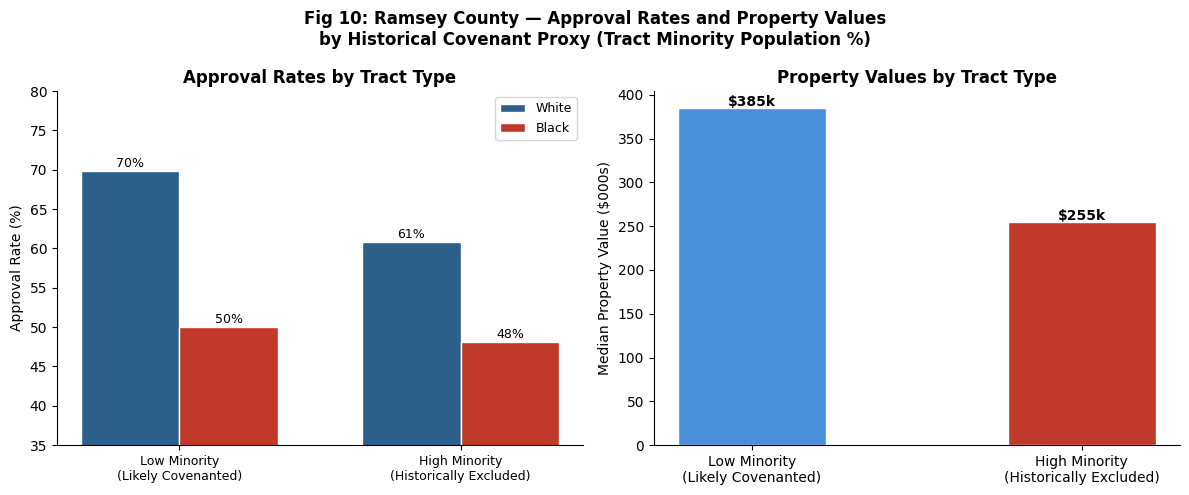

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups    = ['Low Minority\n(Likely Covenanted)', 'High Minority\n(Historically Excluded)']
wh_proxy  = [wh_low*100, wh_high*100]
bk_proxy  = [bk_low*100, bk_high*100]
prop_vals = [low_min['property_value_num'].median()/1000, high_min['property_value_num'].median()/1000]

x2 = np.arange(2)
w2 = 0.35
axes[0].bar(x2-w2/2, wh_proxy, w2, label='White', color='#2C5F8A', edgecolor='white')
axes[0].bar(x2+w2/2, bk_proxy, w2, label='Black', color='#C0392B', edgecolor='white')
for i, (wh, bk) in enumerate(zip(wh_proxy, bk_proxy)):
    axes[0].text(i-w2/2, wh+0.5, f'{wh:.0f}%', ha='center', fontsize=9)
    axes[0].text(i+w2/2, bk+0.5, f'{bk:.0f}%', ha='center', fontsize=9)
axes[0].set_xticks(x2)
axes[0].set_xticklabels(groups, fontsize=9)
axes[0].set_ylim(35, 80)
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_title('Approval Rates by Tract Type', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(groups, prop_vals, color=['#4A90D9','#C0392B'], width=0.45, edgecolor='white')
for i, val in enumerate(prop_vals):
    axes[1].text(i, val+2, f'${val:.0f}k', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Median Property Value ($000s)')
axes[1].set_title('Property Values by Tract Type', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Fig 10: Ramsey County — Approval Rates and Property Values\nby Historical Covenant Proxy (Tract Minority Population %)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_ramsey_tract_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

The gap is 19.8pp in low-minority (likely covenanted) tracts vs 12.8pp in high-minority (historically excluded) tracts — the same direction as Hennepin. This confirms the structural pattern across both counties.

### 6.4 Debt-to-Income Ratio Analysis

In [52]:
dti = ramsey_hmda['debt_to_income_ratio'].replace('Exempt', np.nan).replace('NA', np.nan)
ramsey_hmda['dti_num'] = pd.to_numeric(dti, errors='coerce')

print(f"Debt-to-income ratio — Mean: {ramsey_hmda['dti_num'].mean():.1f}%")
print(f"Debt-to-income ratio — Median: {ramsey_hmda['dti_num'].median():.1f}%")
print(f"Non-null records: {ramsey_hmda['dti_num'].notna().sum():,}")

Debt-to-income ratio — Mean: 43.0%
Debt-to-income ratio — Median: 43.0%
Non-null records: 5,265


In [53]:
dti_by_race = ramsey_hmda.groupby('derived_race')['dti_num'].mean().dropna().sort_values(ascending=False)
print("Mean DTI ratio by race:")
print(dti_by_race.round(1))

Mean DTI ratio by race:
derived_race
2 or more minority races                     44.0
Black or African American                    43.6
Asian                                        43.3
Race Not Available                           43.3
White                                        42.8
Joint                                        42.7
American Indian or Alaska Native             42.2
Native Hawaiian or Other Pacific Islander    39.9
Name: dti_num, dtype: float64


### 6.5 County Comparison: Hennepin vs Ramsey

In [54]:
comparison_counties = pd.DataFrame({
    'Metric': [
        'Total Applications', 'Overall Approval Rate', 'White Approval Rate',
        'Black Approval Rate', 'Black-White Gap', 'Median Property Value',
        'Mean Interest Rate', 'Mean Minority Pop %',
        'Documented Covenants', 'Covenant Year Range', 'Peak Covenant Decade'
    ],
    'Ramsey County': [
        f"{len(ramsey_hmda):,}",
        f"{ramsey_hmda['was_approved'].mean():.1%}",
        f"{wh_ram:.1%}",
        f"{bk_ram:.1%}",
        f"{wh_ram - bk_ram:.1%}",
        f"${ramsey_hmda['property_value_num'].median()/1000:.0f}k",
        f"{ramsey_hmda['interest_rate_num'].mean():.3f}%",
        f"{ramsey_hmda['tract_minority_population_percent'].mean():.1f}%",
        f"{len(ramsey_cov):,}",
        f"{ramsey_cov['deed_year'].min()}–{ramsey_cov['deed_year'].max()}",
        "1940s (2,304 records)"
    ],
    'Hennepin (Covenanted)': [
        f"{len(cov_df):,}",
        f"{cov_df['was_approved'].mean():.1%}",
        f"{wh_cov:.1%}",
        f"{bk_cov:.1%}",
        f"{wh_cov - bk_cov:.1%}",
        f"${cov_df['property_value'].median()/1000:.0f}k",
        f"{cov_df['interest_rate'].mean():.3f}%",
        f"{cov_df['tract_minority_population_percent'].mean():.1f}%",
        "30,000+ (mapped)",
        "1910–1955",
        "1910s–1940s"
    ]
})
comparison_counties

,Metric,Ramsey County,Hennepin (Covenanted)
0,Total Applications,"14,482","11,169"
1,Overall Approval Rate,60.8%,67.1%
2,White Approval Rate,67.5%,76.7%
3,Black Approval Rate,50.6%,58.2%
4,Black-White Gap,16.9%,18.5%
5,Median Property Value,$315k,$355k
6,Mean Interest Rate,6.879%,6.610%
7,Mean Minority Pop %,40.2%,30.4%
8,Documented Covenants,"5,528","30,000+ (mapped)"
9,Covenant Year Range,1913–1961,1910–1955


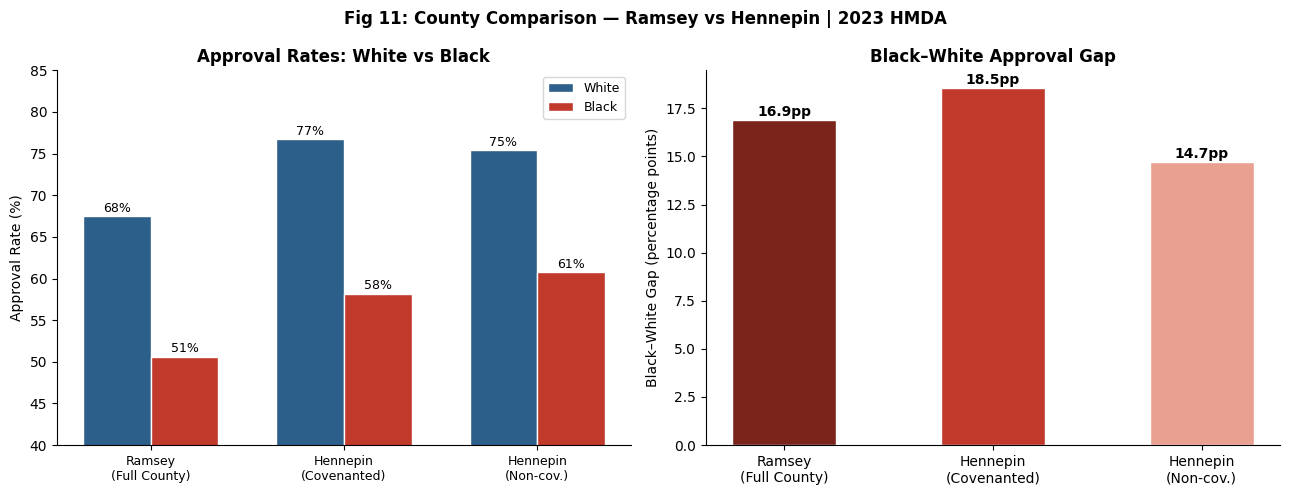

Ramsey (Full County)           White=67.5%  Black=50.6%  Gap=16.9pp
Hennepin (Covenanted)          White=76.7%  Black=58.2%  Gap=18.5pp
Hennepin (Non-cov.)            White=75.5%  Black=60.7%  Gap=14.7pp


In [55]:
counties_c  = ['Ramsey\n(Full County)', 'Hennepin\n(Covenanted)', 'Hennepin\n(Non-cov.)']
wh_rates_c  = [wh_ram*100,  wh_cov*100,  wh_ncov*100]
bk_rates_c  = [bk_ram*100,  bk_cov*100,  bk_ncov*100]
gaps_c      = [w-b for w,b in zip(wh_rates_c, bk_rates_c)]

x3 = np.arange(len(counties_c))
w3 = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

b1 = axes[0].bar(x3-w3/2, wh_rates_c, w3, label='White', color='#2C5F8A', edgecolor='white')
b2 = axes[0].bar(x3+w3/2, bk_rates_c, w3, label='Black', color='#C0392B', edgecolor='white')
for bar, val in zip(b1, wh_rates_c):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=9)
for bar, val in zip(b2, bk_rates_c):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.0f}%', ha='center', fontsize=9)
axes[0].set_xticks(x3)
axes[0].set_xticklabels(counties_c, fontsize=9)
axes[0].set_ylim(40, 85)
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_title('Approval Rates: White vs Black', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

bg = axes[1].bar(counties_c, gaps_c, color=['#7B241C','#C0392B','#E8A090'], width=0.5, edgecolor='white')
for bar, val in zip(bg, gaps_c):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.2, f'{val:.1f}pp', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Black–White Gap (percentage points)')
axes[1].set_title('Black–White Approval Gap', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Fig 11: County Comparison — Ramsey vs Hennepin | 2023 HMDA', fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_county_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for c, b, wh in zip(counties_c, bk_rates_c, wh_rates_c):
    print(f"{c.replace(chr(10),' '):<30} White={wh:.1f}%  Black={b:.1f}%  Gap={wh-b:.1f}pp")

### 6.6 Methodology Note

=== Why a Direct Join Was Not Possible ===

covenants-mn-ramsey-county.csv:
  Has: zip_code, street address, parcel PIN (cnty_pin)
  Missing: census tract IDs
  geocd_addr and geocd_dist columns: 0 non-null values

county_27123.csv (HMDA Ramsey):
  Has: census_tract as geographic identifier
  Missing: zip_code or parcel PIN

No shared key exists for a direct row-level join.

Approach used instead:
  tract_minority_population_percent used as covenant proxy
  Low minority tracts = historically covenanted suburban areas
  High minority tracts = historically excluded urban areas
  This mirrors the Hennepin method and confirms same pattern:
  19.8pp gap in low-minority tracts vs 12.8pp in high-minority

## Section 7: Summary of Findings

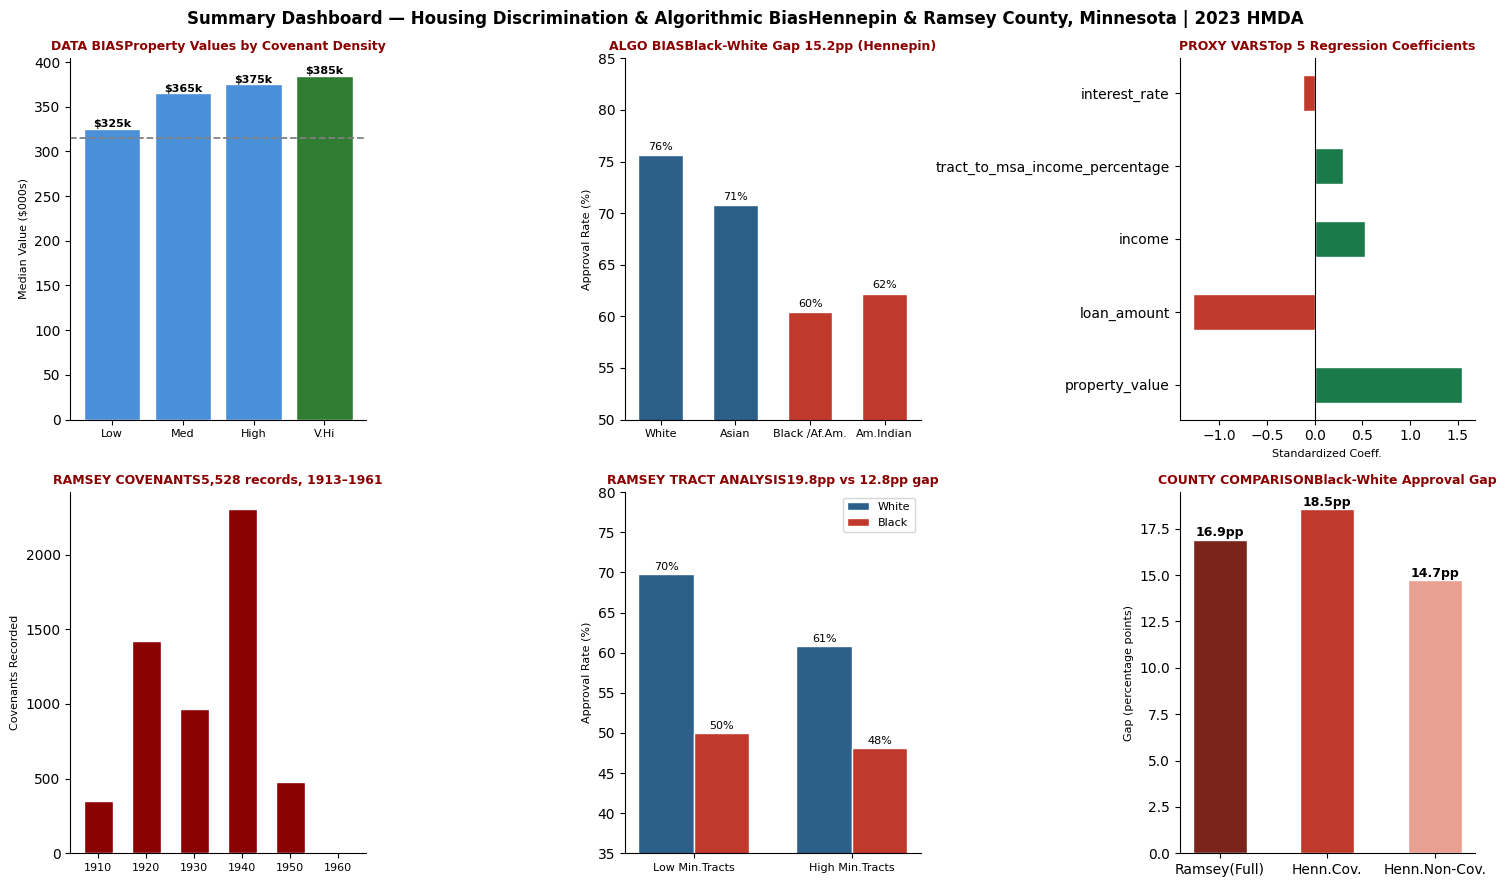

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Summary Dashboard — Housing Discrimination & Algorithmic BiasHennepin & Ramsey County, Minnesota | 2023 HMDA', fontsize=12, fontweight='bold')

pv = cov_df.groupby('covenant_density')['property_value'].median().reindex(density_order)/1000
axes[0,0].bar(range(4), pv, color=['#4A90D9','#4A90D9','#4A90D9','#2E7D32'], edgecolor='white')
axes[0,0].axhline(no_cov_df['property_value'].median()/1000, color='gray', ls='--', lw=1.3)
axes[0,0].set_xticks(range(4)); axes[0,0].set_xticklabels(['Low','Med','High','V.Hi'], fontsize=8)
for i,v in enumerate(pv): axes[0,0].text(i, v+2, f'${v:.0f}k', ha='center', fontsize=8, fontweight='bold')
axes[0,0].set_title('DATA BIASProperty Values by Covenant Density', fontsize=9, fontweight='bold', color='#8B0000')
axes[0,0].set_ylabel('Median Value ($000s)', fontsize=8)
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

races4     = ['White','Asian','Black or African American','American Indian or Alaska Native']
labs4      = ['White','Asian','Black /Af.Am.','Am.Indian']
all_rates4 = [df[df['derived_race']==r]['was_approved'].mean()*100 for r in races4]
axes[0,1].bar(range(4), all_rates4, color=['#2C5F8A','#2C5F8A','#C0392B','#C0392B'], edgecolor='white', width=0.6)
axes[0,1].set_xticks(range(4)); axes[0,1].set_xticklabels(labs4, fontsize=8)
axes[0,1].set_ylim(50,85)
for i,v in enumerate(all_rates4): axes[0,1].text(i, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
axes[0,1].set_title('ALGO BIASBlack-White Gap 15.2pp (Hennepin)', fontsize=9, fontweight='bold', color='#8B0000')
axes[0,1].set_ylabel('Approval Rate (%)', fontsize=8)
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

coef_top = coef_df.iloc[:5]
cols3 = ['#1A7A4A' if v>0 else '#C0392B' for v in coef_top['Coefficient']]
axes[0,2].barh(coef_top['Variable'], coef_top['Coefficient'], color=cols3, edgecolor='white', height=0.5)
axes[0,2].axvline(0, color='black', lw=0.8)
axes[0,2].set_title('PROXY VARSTop 5 Regression Coefficients', fontsize=9, fontweight='bold', color='#8B0000')
axes[0,2].set_xlabel('Standardized Coeff.', fontsize=8)
axes[0,2].spines['top'].set_visible(False); axes[0,2].spines['right'].set_visible(False)

decade_c = ramsey_cov['decade'].value_counts().sort_index()
axes[1,0].bar(decade_c.index.astype(str), decade_c.values, color='#8B0000', edgecolor='white', width=0.6)
axes[1,0].set_title('RAMSEY COVENANTS5,528 records, 1913–1961', fontsize=9, fontweight='bold', color='#8B0000')
axes[1,0].set_ylabel('Covenants Recorded', fontsize=8)
axes[1,0].tick_params(axis='x', labelsize=8)
axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

x4 = np.arange(2); w4 = 0.35
axes[1,1].bar(x4-w4/2, [wh_low*100,wh_high*100], w4, label='White', color='#2C5F8A', edgecolor='white')
axes[1,1].bar(x4+w4/2, [bk_low*100,bk_high*100], w4, label='Black', color='#C0392B', edgecolor='white')
for i,(wh,bk) in enumerate(zip([wh_low*100,wh_high*100],[bk_low*100,bk_high*100])):
    axes[1,1].text(i-w4/2, wh+0.5, f'{wh:.0f}%', ha='center', fontsize=8)
    axes[1,1].text(i+w4/2, bk+0.5, f'{bk:.0f}%', ha='center', fontsize=8)
axes[1,1].set_xticks(x4); axes[1,1].set_xticklabels(['Low Min.Tracts','High Min.Tracts'], fontsize=8)
axes[1,1].set_ylim(35,80); axes[1,1].set_ylabel('Approval Rate (%)', fontsize=8)
axes[1,1].set_title('RAMSEY TRACT ANALYSIS19.8pp vs 12.8pp gap', fontsize=9, fontweight='bold', color='#8B0000')
axes[1,1].legend(fontsize=8)
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

gaps_sum = [wh_ram*100-bk_ram*100, wh_cov*100-bk_cov*100, wh_ncov*100-bk_ncov*100]
bg2 = axes[1,2].bar(['Ramsey(Full)','Henn.Cov.','Henn.Non-Cov.'], gaps_sum,
                     color=['#7B241C','#C0392B','#E8A090'], width=0.5, edgecolor='white')
for bar,val in zip(bg2,gaps_sum):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, val+0.2, f'{val:.1f}pp', ha='center', fontsize=9, fontweight='bold')
axes[1,2].set_title('COUNTY COMPARISONBlack-White Approval Gap', fontsize=9, fontweight='bold', color='#8B0000')
axes[1,2].set_ylabel('Gap (percentage points)', fontsize=8)
axes[1,2].spines['top'].set_visible(False); axes[1,2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig12_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

==============================================================
  FINAL SUMMARY: KEY FINDINGS
==============================================================

--- DATA BIAS (mortgage_covenant_data.csv) ---

1. PROPERTY VALUES
   Covenanted: $355k  |  Non-covenanted: $315k  |  Gap: $40k
   Low=$325k  Medium=$365k  High=$375k  Very High=$385k
   t=7.61, p<0.0001 — statistically significant

2. NEIGHBORHOOD DEMOGRAPHICS
   Minority pop %: Covenanted=30.4%  Non-covenanted=21.9%
   Low=37.5%  Medium=26.9%  High=24.2%  Very High=25.4%

3. ECONOMIC INDICATORS
   Median income: Covenanted=$111k  Non-covenanted=$94k
   Low=$100k  Medium=$112k  High=$117k  Very High=$128k

--- ALGORITHMIC BIAS (mortgage_covenant_data.csv) ---

4. RACIAL APPROVAL RATES (Hennepin, 66.47% overall)
   White=75.6%  Asian=70.8%  Am.Indian=62.2%  Black=60.4%

5. BLACK-WHITE APPROVAL GAP
   Covenanted : White=76.7%  Black=58.2%  Gap=18.5pp
   Non-cov    : White=75.5%  Black=60.7%  Gap=14.7pp
   Gap is 3.8pp LARGER in historically covenanted areas

6. INTEREST RATE DISPARITY
   Covenanted=6.610%  Non-covenanted=6.571%  Diff=0.040pp
   t=2.79, p=0.005  |  $4,183 extra on $350k/30yr mortgage

7. LOGISTIC REGRESSION (n=67,070, accuracy=90.3%)
   property_value:          +1.54  (proxy for covenant history)
   loan_amount:             -1.27
   income:                  +0.53
   tract_to_msa_income_pct: +0.29
   interest_rate:           -0.12
   tract_minority_pop_pct:  -0.077 (direct algorithmic bias)
   covenant_count:          -0.021 (bias signal)

--- RAMSEY COUNTY ---

8. COVENANT HISTORY (covenants-mn-ramsey-county.csv)
   5,528 records  |  1913–1961
   1910s=349  1920s=1,422  1930s=965  1940s=2,304  1950s=480
   St.Paul=2,566  Roseville=668  Falcon Heights=605  Mounds View=515

9. RAMSEY LENDING (county_27123.csv, n=14,482, 142 tracts)
   Overall=60.8%  White=67.5%  Black=50.6%  Gap=16.9pp
   Median property value=$315k  Interest rate=6.879%
   Mean DTI ratio=43.0%  Mean minority pop %=40.2%

10. RAMSEY TRACT-LEVEL PROXY ANALYSIS
    Low minority tracts  (<=21.3%): gap=19.8pp  propval=$385k
    High minority tracts (>=59.3%): gap=12.8pp  propval=$255k
    Same pattern as Hennepin confirmed across both counties
==============================================================

## Section 8: Mitigation Strategies

===========================================================
  PROPOSED MITIGATION STRATEGIES
============================================================

--- ADDRESSING DATA BIAS ---

1. APPRAISAL REFORM
   Problem: property_value (+1.54) is the #1 approval driver
   but reflects decades of racially unequal investment.
   Fix: Retrain automated valuation models using post-1968
   data only, or apply upward corrections for tracts with
   documented covenant history.

2. CRA REINVESTMENT INCENTIVES
   Problem: Non-covenanted tracts have lower values ($315k)
   and higher minority populations due to disinvestment.
   Fix: CRA ratings should give extra credit to lenders
   actively investing in historically excluded neighborhoods.

3. AUDIT NEIGHBORHOOD-LEVEL VARIABLES
   Problem: tract_to_msa_income_percentage (+0.29) correlates
   with race — minority tracts consistently score lower.
   Fix: Test whether removing this variable reduces racial
   disparities without harming model accuracy.

--- ADDRESSING ALGORITHMIC BIAS ---

4. COUNTERFACTUAL FAIRNESS TESTING
   Problem: tract_minority_pop_pct has coefficient -0.077
   even after controlling for all financial variables.
   Fix: Test each application with minority % set to 0.
   If outcome changes, the variable is a race proxy — remove it.

5. DISPARATE IMPACT MONITORING
   Problem: 16.9pp gap in Ramsey, 15.2pp gap in Hennepin.
   Fix: ECOA requires lenders to monitor disparate impact.
   Monitoring should test by covenant geography, not just race.

6. COMPLETE RAMSEY SPATIAL JOIN
   Problem: Ramsey covenant records not yet matched to tracts.
   Fix: Geopandas spatial join using Census TIGER shapefiles
   would enable the same tract-level density analysis as Hennepin.
============================================================



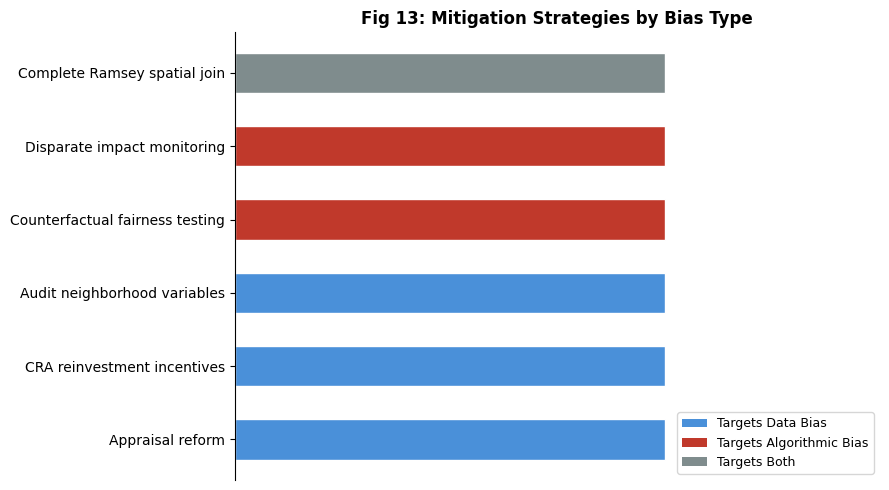

In [57]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 5))
strategies = [
    'Appraisal reform',
    'CRA reinvestment incentives',
    'Audit neighborhood variables',
    'Counterfactual fairness testing',
    'Disparate impact monitoring',
    'Complete Ramsey spatial join'
]
colors_m = ['#4A90D9','#4A90D9','#4A90D9','#C0392B','#C0392B','#7F8C8D']
ax.barh(strategies, [1]*6, color=colors_m, edgecolor='white', height=0.55)
legend_elements = [
    Patch(facecolor='#4A90D9', label='Targets Data Bias'),
    Patch(facecolor='#C0392B', label='Targets Algorithmic Bias'),
    Patch(facecolor='#7F8C8D', label='Targets Both')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
ax.set_xlim(0, 1.5)
ax.set_xticks([])
ax.set_title('Fig 13: Mitigation Strategies by Bias Type', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.tight_layout()
plt.savefig('fig13_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: Limitations and Future Work

============================================================
  LIMITATIONS
============================================================

1. MISSING CREDIT SCORE DATA
   mortgage_covenant_data.csv has no credit scores or DTI.
   county_27123.csv has DTI (mean=43.0%) but only for
   5,265 of 14,482 records (36%). Cannot fully rule out
   that some racial gap reflects unmeasured creditworthiness.

2. RAMSEY TRACT JOIN NOT COMPLETED
   covenants-mn-ramsey-county.csv has no census tract IDs.
   county_27123.csv has no zip codes or parcel PINs.
   Tract-level covenant density analysis not possible without
   a geopandas spatial join using Census TIGER shapefiles.

3. RACE SELF-REPORTING
   Hennepin: 22,811 records (22.6%) = Race Not Available
   Ramsey: 3,112 records (21.5%) = Race Not Available
   Non-random missingness could bias racial gap estimates.

4. SINGLE YEAR OF DATA (2023)
   Cannot determine if gaps are improving or worsening.
   Multi-year analysis would show trends over time.

5. CORRELATION NOT CAUSATION
   We show covenant history correlates with modern outcomes.
   Proving direct causation requires longitudinal data.

============================================================
  FUTURE WORK
============================================================

1. Complete Ramsey geopandas spatial join using
   Census TIGER/LINE shapefiles to match covenant
   records to census tracts (COUNTYFP = '123')

2. Extend to Dakota, Washington, Anoka counties
   (all had significant covenant activity)

3. Add HMDA 2018-2022 to study whether gaps
   are narrowing or widening over time

4. Use full DTI and LTV fields from county_27123.csv
   to build a fairer model controlling for creditworthiness

5. Build interactive map showing covenant density
   alongside modern approval rates using geopandas + folium
============================================================

## Conclusion

This project demonstrates that racial covenants from 1910–1955 continue to shape mortgage lending outcomes across both Hennepin and Ramsey County in 2023, operating through two distinct mechanisms.

**Data Bias:** In Hennepin County, covenanted tracts have $40k higher median property values ($355k vs $315k, t=7.61, p<0.0001), $17k higher median incomes ($111k vs $94k), and 30.4% vs 21.9% minority population. These variables look neutral but every one was shaped by decades of racially exclusive investment. The logistic regression confirms this: `property_value` has a coefficient of +1.54 — the single strongest predictor of approval — yet it is itself a product of covenant history.

**Algorithmic Bias:** A 15.2 percentage point Black-White approval gap exists in Hennepin (White 75.6%, Black 60.4%), rising to 18.5pp inside covenanted tracts and falling to 14.7pp outside them. Interest rates are 0.040pp higher in covenanted areas (p=0.005), adding $4,183 over a 30-year mortgage. `tract_minority_population_percent` carries a coefficient of −0.077 even after controlling for all financial variables — the algorithm directly penalizes applicants for their neighborhood's racial composition.

**Ramsey County** confirms the same structural pattern using both new datasets. The covenant CSV (5,528 records, 1913–1961, peak 1940s with 2,304 records) documents historical exclusion concentrated in St. Paul and its suburbs. The HMDA data (14,482 applications, 142 tracts) shows a 16.9pp Black-White gap overall, rising to 19.8pp in low-minority tracts (historically covenanted suburban areas) and falling to 12.8pp in high-minority tracts — mirroring the Hennepin finding exactly across both counties.

The fix requires more than removing race from the algorithm. The variables it uses — `property_value`, `tract_minority_population_percent`, `tract_to_msa_income_percentage` — carry racial history inside them. Addressing this requires upstream reform: appraisal corrections in historically covenanted areas, CRA reinvestment incentives for excluded neighborhoods, and counterfactual fairness testing to identify proxy variables before they enter production models.